<a href="https://colab.research.google.com/github/AstraLucy/SkinSight/blob/main/skinsight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Testing Model

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
predictions = model(x_train[:1]).numpy()
predictions

array([[-0.2722723 , -0.02652267, -0.16601202, -0.5629397 ,  0.4598228 ,
        -0.19394346, -0.23626736,  0.29029644, -0.20748636,  0.03830742]],
      dtype=float32)

In [ ]:
tf.nn.softmax(predictions).numpy()

array([[0.07985722, 0.10210379, 0.08881012, 0.05971438, 0.16605772,
        0.08636385, 0.08278487, 0.14016344, 0.08520211, 0.10894248]],
      dtype=float32)

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [ ]:
loss_fn(y_train[:1], predictions).numpy()

np.float32(2.449186)

In [ ]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9151 - loss: 0.2938
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9564 - loss: 0.1433
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9669 - loss: 0.1069
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9732 - loss: 0.0869
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9774 - loss: 0.0736


In [ ]:
model.evaluate(x_test,  y_test, verbose=2)

313/313 - 1s - 2ms/step - accuracy: 0.9773 - loss: 0.0751


[0.0751342847943306, 0.9772999882698059]

In [ ]:
probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])

In [ ]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[9.8999379e-08, 2.4481453e-08, 1.0154436e-05, 1.2696332e-04,
        1.0848819e-11, 4.4712166e-07, 5.1883826e-15, 9.9985373e-01,
        2.0381387e-07, 8.3906780e-06],
       [6.4117977e-08, 7.1448470e-03, 9.9280375e-01, 1.0567780e-05,
        1.4694310e-15, 4.0171315e-05, 1.0338341e-08, 6.6948440e-11,
        6.0304109e-07, 9.4289340e-11],
       [6.4944487e-08, 9.9944240e-01, 2.1350499e-05, 8.1596755e-07,
        4.5300421e-05, 6.5969891e-07, 3.9482516e-06, 4.1727730e-04,
        6.6861823e-05, 1.2437797e-06],
       [9.9955350e-01, 3.3314599e-08, 8.3118211e-05, 1.3451185e-07,
        3.2861490e-07, 3.7743114e-06, 2.6347434e-06, 3.3710003e-04,
        2.9698131e-07, 1.9032217e-05],
       [1.7674429e-06, 4.4498580e-07, 5.0225649e-06, 3.5632661e-07,
        9.9801707e-01, 3.8341412e-07, 1.5164228e-05, 1.1829894e-04,
        8.5347489e-07, 1.8406064e-03]], dtype=float32)>

# Skin Sight Model

In [21]:
# Validate GPU is active

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [24]:
# Check GPU

import tensorflow as tf

print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices('GPU'))

Built with CUDA: True
GPUs: []


In [4]:
# Install module tensorflow (necessary on GPU Servers I think)

!pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 768.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 85.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [1]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

train_dir = "/content/drive/MyDrive/Datasets/Skin_Condition_DS"
val_dir = "/content/drive/MyDrive/Datasets/val"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Setup

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os


print("TensorFlow version:", tf.__version__)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow version: 2.21.0


In [6]:
# Parameters

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

In [7]:
# Load Dataset, Split off 70% for training

SEED = 123

data_dir = "/content/drive/MyDrive/Datasets/Skin_Condition_DS"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,   # 30% held out
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 27153 files belonging to 10 classes.
Using 19008 files for training.
Found 27153 files belonging to 10 classes.
Using 8145 files for validation.
Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [8]:
# Split 20% for Validation and 10% for Testing
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

val_size = int(0.67 * temp_batches)  # 20% of total
test_size = temp_batches - val_size  # 10% of total

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

print("Validation batches:", val_size)
print("Test batches:", test_size)

Validation batches: 170
Test batches: 85


In [9]:
# Performance optimization

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [10]:
# Data Augmentation

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [11]:
# Load Pretrained Model

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Freeze base model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
# Build Model

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,362 (9.26 MB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [13]:
# Train Model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 570s 953ms/step - accuracy: 0.5621 - loss: 1.2245 - val_accuracy: 0.6248 - val_loss: 0.9870
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 491s 826ms/step - accuracy: 0.6430 - loss: 0.9396 - val_accuracy: 0.6463 - val_loss: 0.9071
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 491s 827ms/step - accuracy: 0.6657 - loss: 0.8888 - val_accuracy: 0.6623 - val_loss: 0.8694
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 489s 823ms/step - accuracy: 0.6759 - loss: 0.8419 - val_accuracy: 0.6730 - val_loss: 0.8641
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 490s 826ms/step - accuracy: 0.6929 - loss: 0.8137 - val_accuracy: 0.6695 - val_loss: 0.8772
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 491s 826ms/step - accuracy: 0.6967 - loss: 0.8010 - val_accuracy: 0.6748 - val_loss: 0.8695
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 492s 829ms/step - accuracy: 0.7073 - loss: 0.7701 - val_accuracy: 0.6827 - val_loss: 0.8446
Epoch 8/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 492s 828ms/step - accuracy: 0.7124 -

In [ ]:
# Fine-Tuning

base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

Epoch 1/5
249/594 ━━━━━━━━━━━━━━━━━━━━ 6:07 1s/step - accuracy: 0.5715 - loss: 1.1444

In [17]:
# Save Model

model.save("/content/drive/MyDrive/Models/V1/V1.keras")

In [18]:
# Evaluate on Test Data

model.evaluate(test_ds)

85/85 ━━━━━━━━━━━━━━━━━━━━ 62s 636ms/step - accuracy: 0.6924 - loss: 0.8271


[0.827096700668335, 0.6924214363098145]

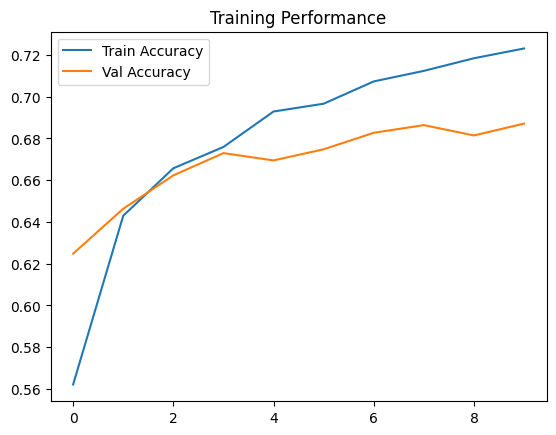

In [19]:
# Plot Results

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.legend()
plt.title("Training Performance")
plt.show()